# Step 1: Load the documents with the help of the pypdf loader.

In [30]:
from langchain_community.document_loaders import PyPDFLoader

In [31]:
loader = PyPDFLoader('intro-to-ml.pdf')

In [32]:
docs = loader.load()

In [33]:
len(docs) #per page one document

392

# Step 2: split the docs into the chunks.

In [34]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
chunks = splitter.split_documents(docs)
len(chunks)

973

# Step 3: convert the chunk documents into the embeddings and store them in a vector store

In [35]:
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings
from dotenv import load_dotenv
load_dotenv()

True

In [36]:
vectorstore = FAISS.from_documents(
    documents = chunks,
    embedding = OpenAIEmbeddings(model = 'text-embedding-3-small')
)

# Create one retriever based on similarity search that will fetch the relevent docs.

In [37]:
retriever = vectorstore.as_retriever(search_type='similarity', search_kwargs={'k': 3})

# Create one rag tool that will fetch the relevent document using retreiver.

In [38]:
from langchain_core.tools import tool   
from langgraph.prebuilt import ToolNode,tools_condition

In [39]:
@tool
def rag_tool(query: str):
    """this function is used to answer questions based on the content of the PDF document"""

    results = retriever.invoke(query)

    context = [doc.page_content for doc in results]
    metadata = [doc.metadata for doc in results]

    return {
        'query': query,
        'context':context,
        'metadata': metadata
    }
rag_tools =[rag_tool]

# Create a llm and bind it will tool

In [40]:
from langchain_openai import ChatOpenAI


In [41]:
llm = ChatOpenAI(model = 'gpt-4o-mini').bind_tools(rag_tools)

# Now create the workflow and call the llm_with_tools with the help of tool_condition

In [42]:
from langgraph.graph import StateGraph ,START,END
from typing import Annotated,Literal,TypedDict
from langgraph.graph.message import BaseMessage,add_messages


In [43]:
class chatState(TypedDict):
    messages : Annotated[list[BaseMessage],add_messages]

In [44]:
def chat_node(state: chatState):
    messages = state['messages']
    response = llm.invoke(messages)

    return {'messages':response}

In [45]:
builder = StateGraph(chatState)

In [46]:
builder.add_node('chat_node',chat_node)
builder.add_node('tool_node',ToolNode(tools=rag_tools))

builder.add_edge(START,'chat_node')
builder.add_conditional_edges(
    source='chat_node',
    path=tools_condition,
    path_map={
        'tools': 'tool_node',
        '__end__': END 
    }
)
builder.add_edge('tool_node','chat_node')

chatbot = builder.compile()

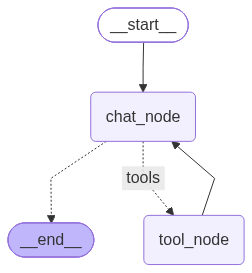

In [47]:
chatbot

In [48]:
from langchain_core.messages import HumanMessage

In [50]:
chatbot.invoke({
    'messages':[HumanMessage(content="using the pdf ,What is the difference between supervised and unsupervised learning?")]
})

{'messages': [HumanMessage(content='using the pdf ,What is the difference between supervised and unsupervised learning?', additional_kwargs={}, response_metadata={}, id='ca805dc9-2667-4f98-bc30-cf942d6e55ad'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 22, 'prompt_tokens': 69, 'total_tokens': 91, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': None, 'text_tokens': None, 'image_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': 0, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None, 'video_tokens': 0}, 'cost': 2.355e-05, 'is_byok': False, 'cost_details': {'upstream_inference_cost': 2.355e-05, 'upstream_inference_prompt_cost': 1.035e-05, 'upstream_inference_completions_cost': 1.32e-05}}, 'model_provider': 'openai', 'model_name': 'openai/gpt-4o-mini', 'system_fingerprint': 'fp_53c3b1e564',

In [51]:
result = chatbot.invoke(
    {
        "messages": [
            HumanMessage(
                content=(
                    "Using the pdf notes, explain how to find the ideal value of K in KNN"
                )
            )
        ]
    }
)

In [52]:

print(result['messages'][-1].content)

To find the ideal value of \( K \) in the K-Nearest Neighbors (KNN) algorithm, consider the following points from the notes:

1. **Understanding KNN**: KNN is a straightforward and effective algorithm where the number of neighbors (\( K \)) significantly influences the performance of the model. 

2. **Parameter Tuning**: The default practice is to start with a small number of neighbors, such as 3 or 5, which often yields good results. However, it is crucial to experiment with different values of \( K \).

3. **Influence of \( K \) on Prediction**: A smaller \( K \) (like 1 neighbor) aligns closely with the training data, leading to noisy and unstable predictions. In contrast, a larger \( K \) smoothes the predictions by averaging over more neighbors, which can result in better generalization and less overfitting.

4. **Validation Techniques**: To find the optimal \( K \), you can use techniques like cross-validation, where you test different values of \( K \) on training sets and valid